In [1]:
# Hyperliquid Trader Performance Analysis Using Bitcoin Market Sentiment

## Objective

#This project analyzes the relationship between trader performance and Bitcoin market sentiment using Hyperliquid historical trader data and the Bitcoin Fear & Greed Index.

#The goal is to identify how profitability, win rate, position sizing, asset performance, and trader behavior change across different sentiment regimes such as Fear, Greed, Extreme Fear, Extreme Greed, and Neutral.

import pandas as pd

trades = pd.read_csv("../data/raw/historical_trader_data.csv")
sentiment = pd.read_csv("../data/raw/fear_greed_index.csv")

print("Trader Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

print("\nTrader Columns:")
print(trades.columns.tolist())

print("\nSentiment Columns:")
print(sentiment.columns.tolist())


C:\Users\Pralisha Tripathy\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Pralisha Tripathy\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Trader Shape: (211224, 16)
Sentiment Shape: (2644, 4)

Trader Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']


In [2]:
print("===== TRADER DATA =====")
print(trades.info())

print("\nMissing Values:")
print(trades.isnull().sum())

print("\n")

print("===== SENTIMENT DATA =====")
print(sentiment.info())

print("\nMissing Values:")
print(sentiment.isnull().sum())

print("\nUnique Sentiment Classes:")
print(sentiment["classification"].value_counts())

===== TRADER DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
d

In [3]:
print("Trader Timestamp IST Sample:")
print(trades["Timestamp IST"].head())

print("\nTrader Timestamp Sample:")
print(trades["Timestamp"].head())

print("\nSentiment Date Sample:")
print(sentiment["date"].head())

Trader Timestamp IST Sample:
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

Trader Timestamp Sample:
0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

Sentiment Date Sample:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [4]:
trades["trade_date"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
).dt.date

sentiment["sentiment_date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

print(trades["trade_date"].head())
print(sentiment["sentiment_date"].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: trade_date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: sentiment_date, dtype: object


In [5]:
print("Trader Date Range")
print(trades["trade_date"].min())
print(trades["trade_date"].max())

print("\nSentiment Date Range")
print(sentiment["sentiment_date"].min())
print(sentiment["sentiment_date"].max())

Trader Date Range
2023-05-01
2025-05-01

Sentiment Date Range
2018-02-01
2025-05-02


In [6]:
## Data Preparation and Sentiment Integration

##The trader dataset contains individual trade-level records, while the sentiment dataset provides daily Bitcoin market sentiment classifications. To combine both datasets, trade timestamps were converted into date format and merged with the sentiment data using the trading date.

merged_df = trades.merge(
    sentiment,
    left_on="trade_date",
    right_on="sentiment_date",
    how="left"
)

print("Merged Shape:", merged_df.shape)

print("\nMissing Sentiment Labels:")
print(merged_df["classification"].isna().sum())

merged_df.head()

Merged Shape: (211224, 22)

Missing Sentiment Labels:
6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date,sentiment_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,2024-12-02


In [7]:
merged_df = merged_df.dropna(subset=["classification"])

merged_df.to_csv(
    "../data/processed/master_trader_sentiment_dataset.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [8]:
## Realized Trade Filtering

##The dataset contains both position-opening and position-closing events. Since profitability is only realized when positions are closed, the analysis focuses on realized trade events such as Close Long, Close Short, and Sell. This prevents zero-PnL opening events from diluting the profitability analysis.

sentiment_performance = merged_df.groupby("classification").agg(
    Trades=("Closed PnL", "count"),
    Total_PnL=("Closed PnL", "sum"),
    Average_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Total_Volume=("Size USD", "sum")
).round(2)

sentiment_performance.sort_values(
    by="Average_PnL",
    ascending=False
)

,Trades,Total_PnL,Average_PnL,Median_PnL,Total_Volume
classification,,,,,
Extreme Greed,39992,2715171.31,67.89,0.0,1.244652e+08
Fear,61837,3357155.44,54.29,0.0,4.833248e+08
Greed,50303,2150129.27,42.74,0.0,2.885825e+08
Extreme Fear,21400,739110.25,34.54,0.0,1.144843e+08
Neutral,37686,1292920.68,34.31,0.0,1.802421e+08


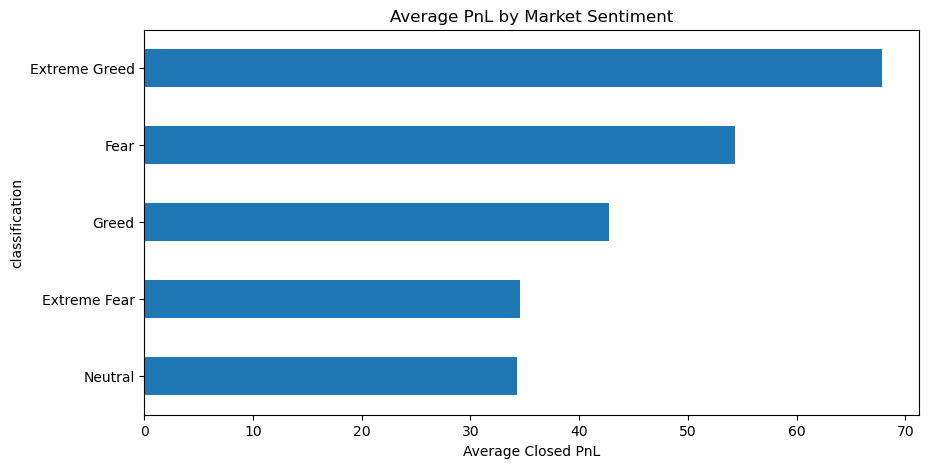

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

sentiment_performance["Average_PnL"].sort_values().plot(
    kind="barh"
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Average Closed PnL")
plt.show()

In [11]:
merged_df["Winning_Trade"] = merged_df["Closed PnL"] > 0

win_rate = (
    merged_df
    .groupby("classification")["Winning_Trade"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(win_rate)

classification
Extreme Greed    46.49
Fear             42.08
Neutral          39.70
Greed            38.48
Extreme Fear     37.06
Name: Winning_Trade, dtype: float64


In [12]:
profitability_summary = merged_df.groupby("classification").agg(
    Trades=("Closed PnL","count"),
    Winning_Trades=("Winning_Trade","sum")
)

profitability_summary["Win_Rate_%"] = (
    profitability_summary["Winning_Trades"]
    / profitability_summary["Trades"]
    * 100
).round(2)

profitability_summary

,Trades,Winning_Trades,Win_Rate_%
classification,,,
Extreme Fear,21400,7931,37.06
Extreme Greed,39992,18594,46.49
Fear,61837,26019,42.08
Greed,50303,19358,38.48
Neutral,37686,14961,39.70


In [13]:
direction_analysis = (
    merged_df
    .groupby(["classification", "Direction"])
    .agg(
        Trades=("Closed PnL","count"),
        Avg_PnL=("Closed PnL","mean"),
        Total_PnL=("Closed PnL","sum")
    )
    .round(2)
)

direction_analysis

Trades   Avg_PnL   Total_PnL
classification Direction                                              
Extreme Fear   Buy                           807      0.00        0.00
               Close Long                   6241     81.20   506752.79
               Close Short                  3117    123.40   384638.54
               Long > Short                    5      1.33        6.66
               Open Long                    7005      0.00        0.00
               Open Short                   3174      0.00        0.00
               Sell                         1042   -135.02  -140692.64
               Short > Long                    6  -1932.52   -11595.10
               Spot Dust Conversion            3      0.00        0.00
Extreme Greed  Buy                          5132      0.00        0.00
               Close Long                   7186     61.83   444316.00
               Close Short                  6497     28.97   188221.27
               Long > Short                    7    120.60      844.21
               Open Long                    6300      0.00        0.00
               Open Short                   7663      0.00        0.00
               Sell                         7164    290.57  2081660.35
               Short > Long                   11     11.77      129.48
               Spot Dust Conversion           32      0.00        0.00
Fear           Buy                          3207      0.00        0.00
               Close Long                  17260     83.00  1432581.92
               Close Short                  9221    207.68  1914986.46
               Long > Short                   14      4.80       67.14
               Open Long                   17824      0.00        0.00
               Open Short                  10887      0.00        0.00
               Sell                         3364     -3.14   -10567.05
               Short > Long                   18   1115.94    20086.98
               Spot Dust Conversion           42      0.00        0.00
Greed          Auto-Deleveraging               8   7184.81    57478.46
               Buy                          4685      0.00        0.00
               Close Long                   7998     88.96   711490.52
               Close Short                 11322     55.20   624923.40
               Liquidated Isolated Short       1 -12752.91   -12752.91
               Long > Short                   16     22.71      363.39
               Open Long                    8544      0.00        0.00
               Open Short                  11664      0.00        0.00
               Sell                         5986    128.02   766340.32
               Settlement                      1    -29.22      -29.22
               Short > Long                   23    100.67     2315.31
               Spot Dust Conversion           55      0.00        0.00
Neutral        Buy                          2885      0.00        0.00
               Close Long                   9993     52.82   527788.16
               Close Short                  5850     94.80   554558.43
               Long > Short                   15     47.33      709.98
               Open Long                   10222      0.00        0.00
               Open Short                   6353      0.00        0.00
               Sell                         2346     89.52   210007.44
               Short > Long                   12    -11.95     -143.34
               Spot Dust Conversion           10      0.00        0.00

In [14]:
direction_winrate = (
    merged_df.assign(
        Winning_Trade = merged_df["Closed PnL"] > 0
    )
    .groupby(["classification","Direction"])
    ["Winning_Trade"]
    .mean()
    .mul(100)
    .round(2)
)

direction_winrate

classification  Direction                
Extreme Fear    Buy                            0.00
                Close Long                    84.65
                Close Short                   70.58
                Long > Short                 100.00
                Open Long                      0.00
                Open Short                     0.00
                Sell                          42.03
                Short > Long                  83.33
                Spot Dust Conversion           0.00
Extreme Greed   Buy                            0.00
                Close Long                    88.77
                Close Short                   85.86
                Long > Short                  85.71
                Open Long                      0.00
                Open Short                     0.00
                Sell                          92.43
                Short > Long                  81.82
                Spot Dust Conversion           0.00
Fear            Buy   

In [15]:
analysis_df = merged_df[
    merged_df["Direction"].isin([
        "Close Long",
        "Close Short",
        "Sell"
    ])
].copy()

print("Shape:", analysis_df.shape)

print(
    analysis_df["Direction"]
    .value_counts()
)

Shape: (104587, 23)
Direction
Close Long     48678
Close Short    36007
Sell           19902
Name: count, dtype: int64


In [16]:
clean_performance = (
    analysis_df
    .groupby("classification")
    .agg(
        Trades=("Closed PnL","count"),
        Total_PnL=("Closed PnL","sum"),
        Avg_PnL=("Closed PnL","mean")
    )
    .round(2)
)

clean_performance

,Trades,Total_PnL,Avg_PnL
classification,,,
Extreme Fear,10400,750698.69,72.18
Extreme Greed,20847,2714197.62,130.20
Fear,29845,3337001.33,111.81
Greed,25306,2102754.24,83.09
Neutral,18189,1292354.03,71.05


In [17]:
analysis_df["Winning_Trade"] = (
    analysis_df["Closed PnL"] > 0
)

clean_winrate = (
    analysis_df
    .groupby("classification")
    ["Winning_Trade"]
    .mean()
    .mul(100)
    .round(2)
)

clean_winrate

classification
Extreme Fear     76.16
Extreme Greed    89.12
Fear             87.10
Greed            76.34
Neutral          82.14
Name: Winning_Trade, dtype: float64

In [18]:
top_coins = (
    analysis_df
    .groupby("Coin")
    .agg(
        Trades=("Closed PnL","count"),
        Total_PnL=("Closed PnL","sum"),
        Avg_PnL=("Closed PnL","mean")
    )
    .sort_values("Total_PnL", ascending=False)
    .head(15)
)

top_coins

,Trades,Total_PnL,Avg_PnL
Coin,,,
@107,17166,2.783913e+06,162.175983
HYPE,31985,1.948062e+06,60.905483
SOL,5016,1.628228e+06,324.606944
ETH,5205,1.314432e+06,252.532494
BTC,11026,8.862948e+05,80.382264
MELANIA,2209,3.891310e+05,176.157091
ENA,331,2.106171e+05,636.305529
SUI,890,1.991583e+05,223.773394
DOGE,458,1.475013e+05,322.055257


In [19]:
analysis_df["Coin"].nunique()

221

In [20]:
top_traders = (
    analysis_df
    .groupby("Account")
    .agg(
        Trades=("Closed PnL","count"),
        Total_PnL=("Closed PnL","sum"),
        Avg_PnL=("Closed PnL","mean")
    )
    .sort_values("Total_PnL", ascending=False)
    .head(10)
)

top_traders

,Trades,Total_PnL,Avg_PnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6512,2.143319e+06,329.133770
0x083384f897ee0f19899168e3b1bec365f52a9012,1731,1.599060e+06,923.778140
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9997,9.401638e+05,94.044594
0x513b8629fe877bb581bf244e326a047b249c4ff1,5511,8.587445e+05,155.823709
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,22537,8.358066e+05,37.085973
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,2233,6.777471e+05,303.514129
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,737,4.293556e+05,582.572003
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8672,3.756378e+05,43.316163
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,558,3.605395e+05,646.128154


In [21]:
top_coins = (
    analysis_df
    .groupby("Coin")
    .agg(
        Trades=("Closed PnL", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Avg_PnL=("Closed PnL", "mean"),
        Win_Rate=("Winning_Trade", lambda x: round(x.mean() * 100, 2))
    )
    .sort_values("Total_PnL", ascending=False)
    .head(15)
)

top_coins

,Trades,Total_PnL,Avg_PnL,Win_Rate
Coin,,,,
@107,17166,2.783913e+06,162.175983,81.70
HYPE,31985,1.948062e+06,60.905483,88.15
SOL,5016,1.628228e+06,324.606944,83.85
ETH,5205,1.314432e+06,252.532494,76.87
BTC,11026,8.862948e+05,80.382264,82.82
MELANIA,2209,3.891310e+05,176.157091,88.91
ENA,331,2.106171e+05,636.305529,93.35
SUI,890,1.991583e+05,223.773394,93.93
DOGE,458,1.475013e+05,322.055257,87.55


In [22]:
print("Total unique coins traded:", analysis_df["Coin"].nunique())

Total unique coins traded: 221


In [23]:
coin_sentiment = (
    analysis_df
    .groupby(["classification", "Coin"])
    .agg(
        Trades=("Closed PnL", "count"),
        Total_PnL=("Closed PnL", "sum"),
        Avg_PnL=("Closed PnL", "mean")
    )
    .reset_index()
)

top_coin_sentiment = (
    coin_sentiment
    .sort_values(["classification", "Total_PnL"], ascending=[True, False])
    .groupby("classification")
    .head(5)
)

top_coin_sentiment

,classification,Coin,Trades,Total_PnL,Avg_PnL
34,Extreme Fear,HYPE,4759,4.820838e+05,101.299387
26,Extreme Fear,ETH,783,2.694529e+05,344.128809
54,Extreme Fear,SOL,863,1.051795e+05,121.876598
41,Extreme Fear,MELANIA,350,9.737917e+04,278.226192
55,Extreme Fear,SUI,160,4.478247e+04,279.890463
67,Extreme Greed,@107,6341,1.988619e+06,313.612817
143,Extreme Greed,HYPE,2405,1.596866e+05,66.397737
117,Extreme Greed,BTC,978,1.008830e+05,103.152329
180,Extreme Greed,PURR/USDC,713,7.750659e+04,108.704893
189,Extreme Greed,SOL,780,3.770697e+04,48.342271


In [24]:
top_traders = (
    analysis_df
    .groupby("Account")
    .agg(
        Trades=("Closed PnL","count"),
        Total_PnL=("Closed PnL","sum"),
        Avg_PnL=("Closed PnL","mean"),
        Win_Rate=("Winning_Trade", lambda x: round(x.mean()*100,2))
    )
    .sort_values("Total_PnL", ascending=False)
)

top_traders.head(15)

,Trades,Total_PnL,Avg_PnL,Win_Rate
Account,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6512,2.143319e+06,329.133770,76.09
0x083384f897ee0f19899168e3b1bec365f52a9012,1731,1.599060e+06,923.778140,79.26
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9997,9.401638e+05,94.044594,99.12
0x513b8629fe877bb581bf244e326a047b249c4ff1,5511,8.587445e+05,155.823709,89.06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,22537,8.358066e+05,37.085973,76.28
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,2233,6.777471e+05,303.514129,94.85
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,737,4.293556e+05,582.572003,74.63
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8672,3.756378e+05,43.316163,92.40
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,558,3.605395e+05,646.128154,77.42


In [25]:
print("Unique Traders:", analysis_df["Account"].nunique())

Unique Traders: 32


In [26]:
top10_share = (
    top_traders.head(10)["Total_PnL"].sum()
    /
    top_traders["Total_PnL"].sum()
) * 100

print("Top 10 Traders Contribution (%):", round(top10_share,2))

Top 10 Traders Contribution (%): 84.14


In [27]:
size_analysis = (
    analysis_df
    .groupby("classification")
    .agg(
        Avg_Size_USD=("Size USD","mean"),
        Median_Size_USD=("Size USD","median"),
        Avg_PnL=("Closed PnL","mean")
    )
    .round(2)
)

size_analysis

,Avg_Size_USD,Median_Size_USD,Avg_PnL
classification,,,
Extreme Fear,5432.67,834.97,72.18
Extreme Greed,2775.65,435.97,130.20
Fear,8011.26,749.79,111.81
Greed,5450.97,554.99,83.09
Neutral,5532.58,554.99,71.05


In [28]:
correlation = analysis_df[
    ["Size USD","Closed PnL"]
].corr()

correlation

,Size USD,Closed PnL
Size USD,1.000000,0.163623
Closed PnL,0.163623,1.000000


In [29]:
fee_analysis = (
    analysis_df
    .groupby("classification")
    .agg(
        Avg_Fee=("Fee","mean"),
        Avg_PnL=("Closed PnL","mean")
    )
    .round(4)
)

fee_analysis

,Avg_Fee,Avg_PnL
classification,,
Extreme Fear,1.1716,72.1826
Extreme Greed,0.6546,130.1961
Fear,1.5712,111.8111
Greed,1.1875,83.0931
Neutral,1.2209,71.0514


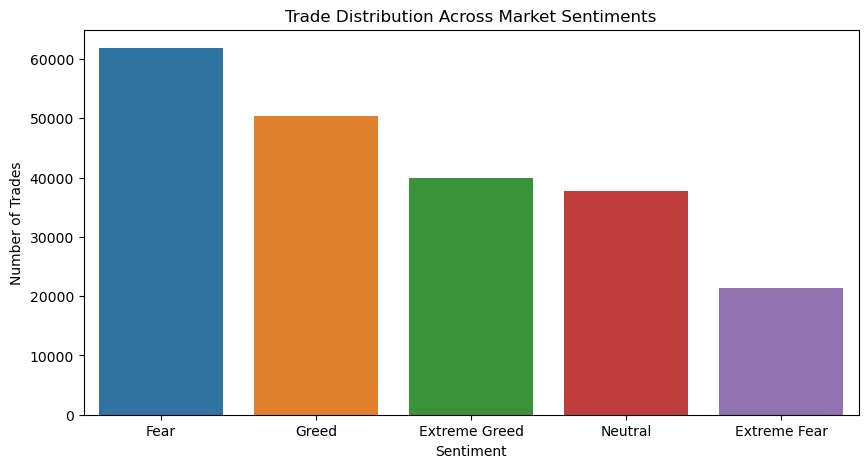

In [30]:
## Exploratory Data Analysis and Visual Insights

#The following visualizations summarize how trader profitability, win rate, trading volume, asset behavior, and position sizing vary across different market sentiment conditions.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.title("Trade Distribution Across Market Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

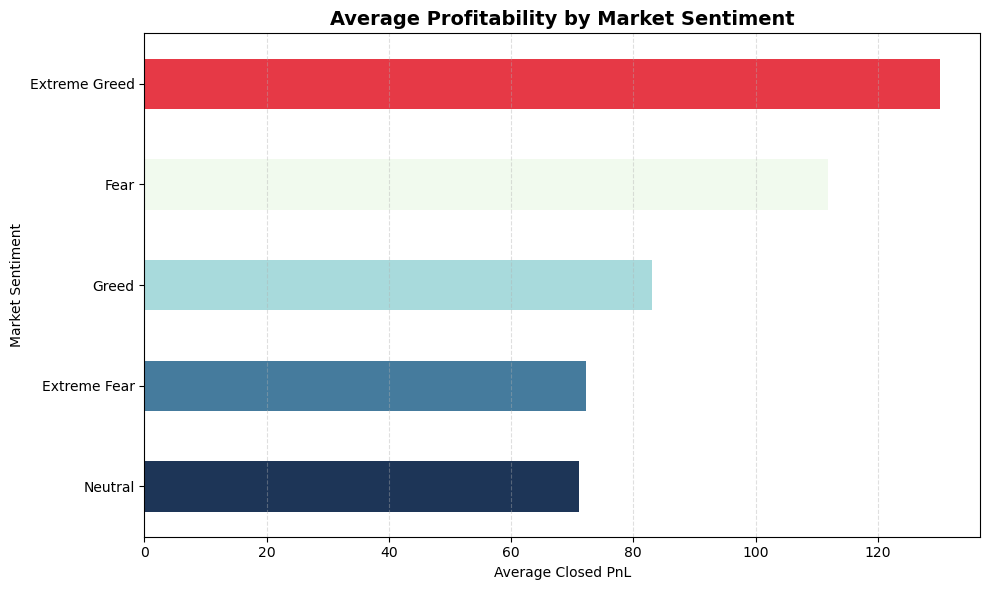

In [47]:
plt.figure(figsize=(10,6))

colors = ["#1D3557", "#457B9D", "#A8DADC", "#F1FAEE", "#E63946"]

clean_performance["Avg_PnL"].sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Average Profitability by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Average Closed PnL")
plt.ylabel("Market Sentiment")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/avg_pnl_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

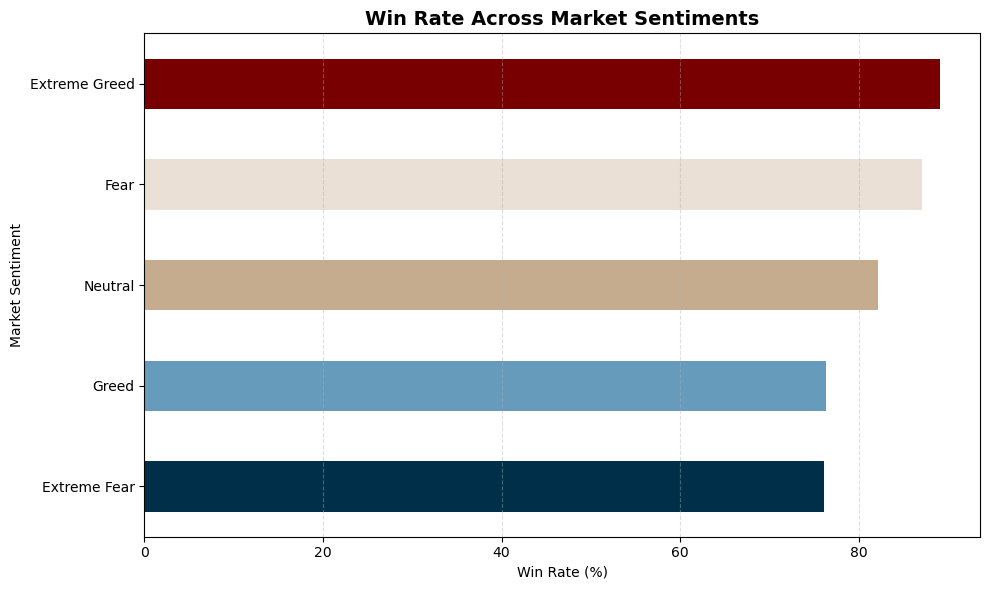

In [48]:
plt.figure(figsize=(10,6))

colors = ["#003049", "#669BBC", "#C6AC8F", "#EAE0D5", "#780000"]

clean_winrate.sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Win Rate Across Market Sentiments", fontsize=14, fontweight="bold")
plt.xlabel("Win Rate (%)")
plt.ylabel("Market Sentiment")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/win_rate_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

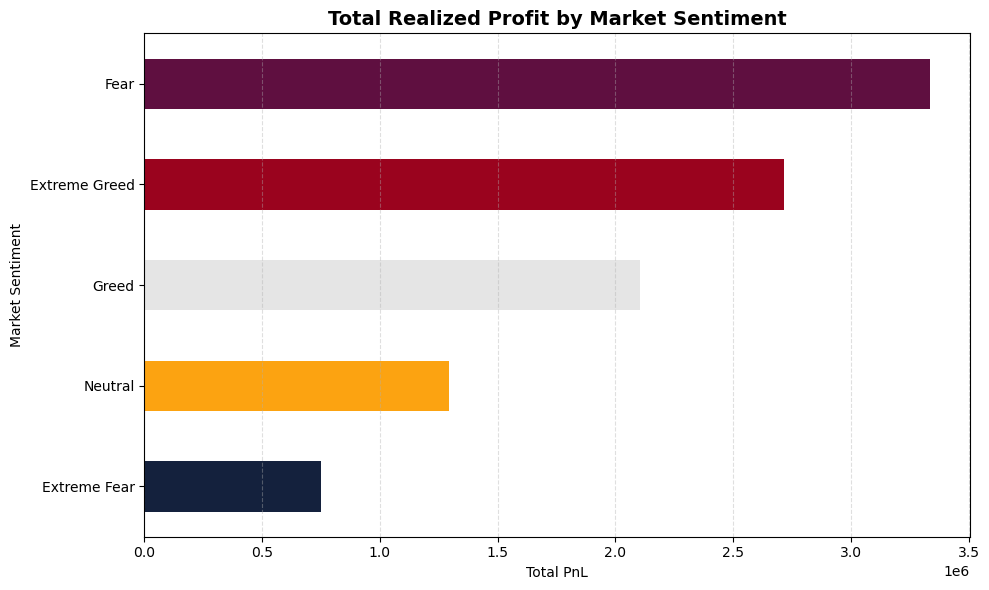

In [49]:
plt.figure(figsize=(10,6))

colors = ["#14213D", "#FCA311", "#E5E5E5", "#9A031E", "#5F0F40"]

clean_performance["Total_PnL"].sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Total Realized Profit by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Total PnL")
plt.ylabel("Market Sentiment")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/total_pnl_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

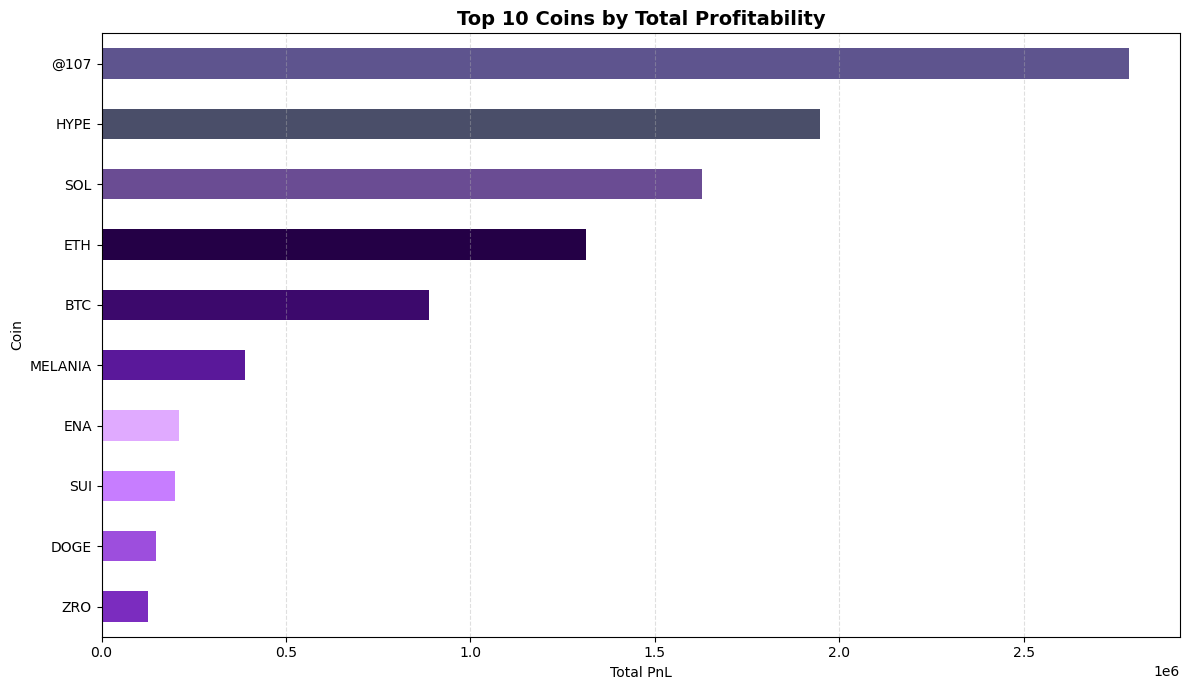

In [50]:
plt.figure(figsize=(12,7))

colors = [
    "#7B2CBF",
    "#9D4EDD",
    "#C77DFF",
    "#E0AAFF",
    "#5A189A",
    "#3C096C",
    "#240046",
    "#6A4C93",
    "#4A4E69",
    "#5E548E"
]

top_coins.head(10)["Total_PnL"].sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Top 10 Coins by Total Profitability", fontsize=14, fontweight="bold")
plt.xlabel("Total PnL")
plt.ylabel("Coin")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/top_coins.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

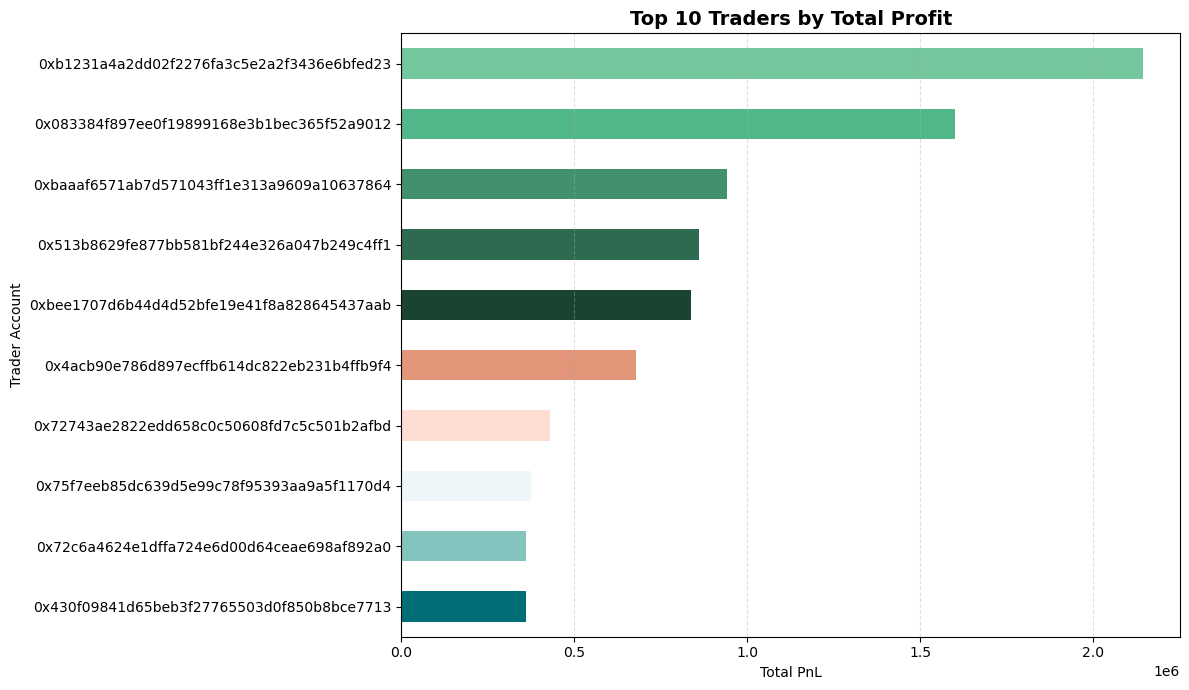

In [51]:
plt.figure(figsize=(12,7))

colors = [
    "#006D77",
    "#83C5BE",
    "#EDF6F9",
    "#FFDDD2",
    "#E29578",
    "#1B4332",
    "#2D6A4F",
    "#40916C",
    "#52B788",
    "#74C69D"
]

top_traders.head(10)["Total_PnL"].sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Top 10 Traders by Total Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total PnL")
plt.ylabel("Trader Account")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/top_traders.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

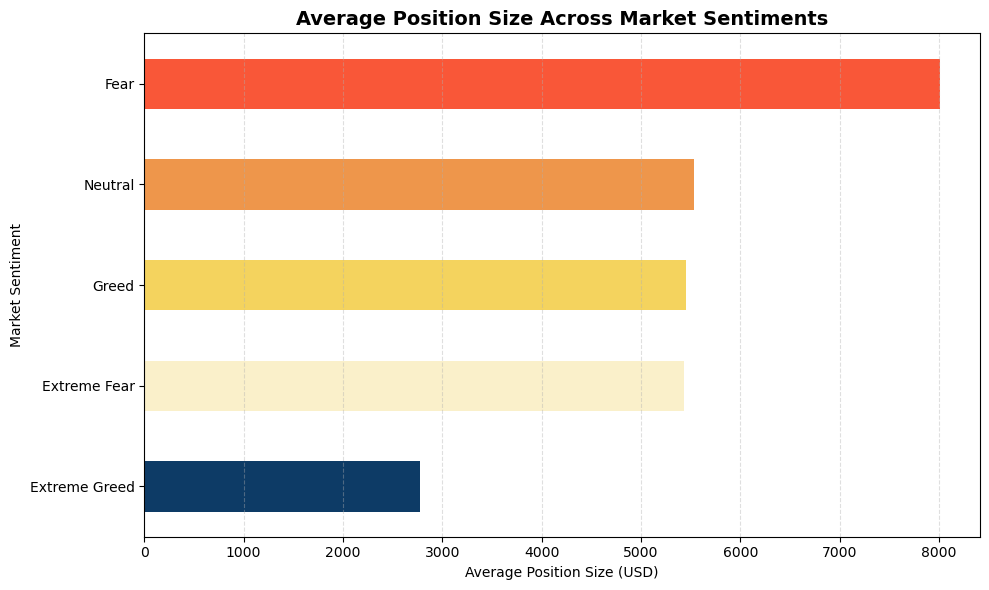

In [52]:
plt.figure(figsize=(10,6))

colors = ["#0D3B66", "#FAF0CA", "#F4D35E", "#EE964B", "#F95738"]

size_analysis["Avg_Size_USD"].sort_values().plot(
    kind="barh",
    color=colors
)

plt.title("Average Position Size Across Market Sentiments", fontsize=14, fontweight="bold")
plt.xlabel("Average Position Size (USD)")
plt.ylabel("Market Sentiment")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/position_size_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

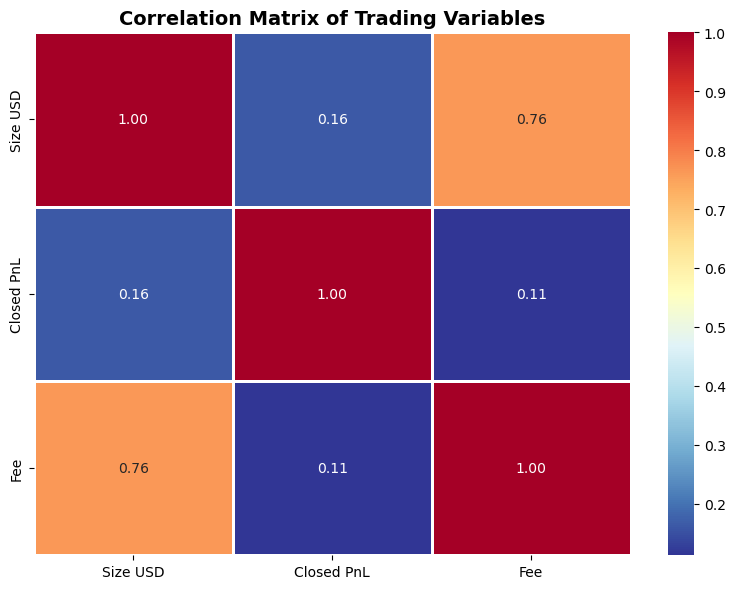

In [53]:
plt.figure(figsize=(8,6))

sns.heatmap(
    analysis_df[
        ["Size USD","Closed PnL","Fee"]
    ].corr(),
    annot=True,
    cmap="RdYlBu_r",
    linewidths=1,
    fmt=".2f"
)

plt.title("Correlation Matrix of Trading Variables", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

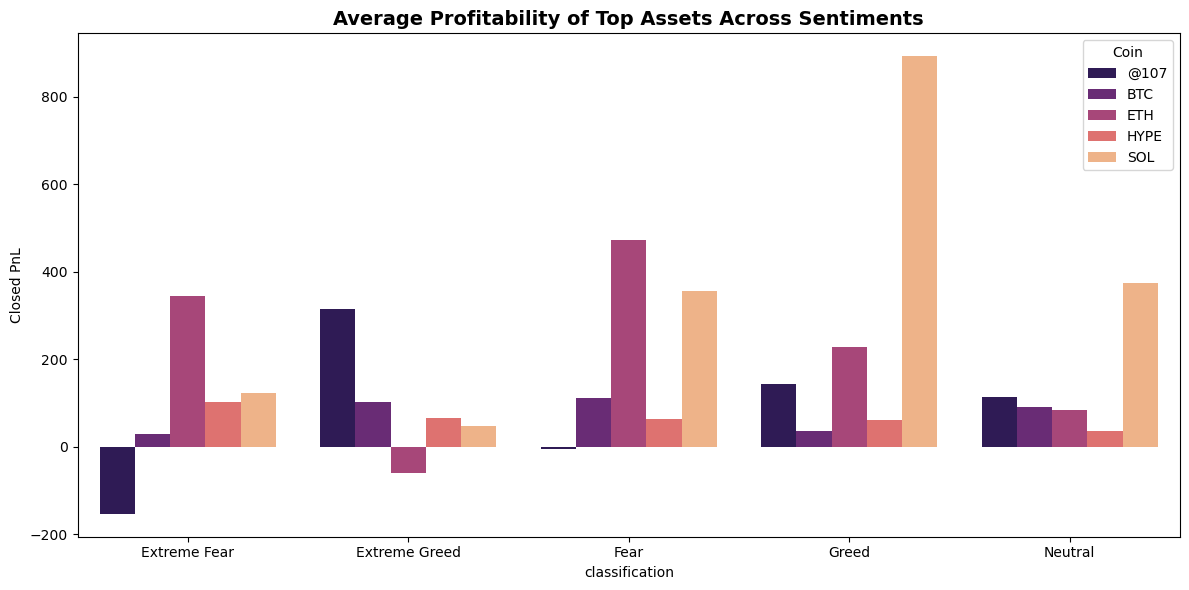

In [54]:
top5_coins = ["@107", "HYPE", "SOL", "ETH", "BTC"]

coin_plot = (
    analysis_df[
        analysis_df["Coin"].isin(top5_coins)
    ]
    .groupby(["classification", "Coin"])["Closed PnL"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=coin_plot,
    x="classification",
    y="Closed PnL",
    hue="Coin",
    palette="magma"
)

plt.title(
    "Average Profitability of Top Assets Across Sentiments",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/coin_sentiment_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

sentiment_performance.to_csv("../outputs/tables/sentiment_performance.csv")
clean_performance.to_csv("../outputs/tables/clean_performance.csv")
clean_winrate.to_csv("../outputs/tables/clean_winrate.csv")
top_coins.to_csv("../outputs/tables/top_coins.csv")
top_traders.to_csv("../outputs/tables/top_traders.csv")
size_analysis.to_csv("../outputs/tables/size_analysis.csv")
fee_analysis.to_csv("../outputs/tables/fee_analysis.csv")

print("All output tables saved successfully.")

All output tables saved successfully.


In [38]:
print("="*80)
print("KEY INSIGHTS & STRATEGIC FINDINGS")
print("="*80)

print("\n1. MARKET SENTIMENT IMPACT")
print("-"*80)
print("• Extreme Greed delivered the highest average profitability ($130.20 per trade).")
print("• Fear markets generated the second-highest average profitability ($111.81 per trade).")
print("• Profitability varies significantly across sentiment regimes, confirming that market sentiment influences trader performance.")

print("\n2. WIN RATE ANALYSIS")
print("-"*80)
print("• Extreme Greed achieved the highest win rate (89.12%).")
print("• Fear achieved a strong win rate of 87.10%, outperforming normal Greed (76.34%).")
print("• Strong sentiment environments produced better outcomes than Neutral conditions.")

print("\n3. TRADING ACTIVITY & MARKET PARTICIPATION")
print("-"*80)
print("• Fear periods recorded the highest trading activity and trading volume.")
print("• Traders appear to participate more aggressively during uncertain market conditions.")
print("• Elevated volatility during Fear phases may create more trading opportunities.")

print("\n4. ASSET PERFORMANCE")
print("-"*80)
print("• The most profitable assets were @107, HYPE, SOL, ETH, and BTC.")
print("• SOL consistently generated exceptional profits across multiple sentiment regimes.")
print("• ETH showed particularly strong performance during Fear and Extreme Fear periods.")
print("• HYPE emerged as the most actively traded asset in the dataset.")

print("\n5. TRADER CONCENTRATION")
print("-"*80)
print("• Only 32 unique traders were present in the dataset.")
print("• The top 10 traders generated 84.14% of total profits.")
print("• Profitability is highly concentrated among a small group of high-performing traders.")
print("• This suggests that trading skill and strategy quality significantly impact outcomes.")

print("\n6. RISK & POSITION SIZING")
print("-"*80)
print("• Fear periods had the largest average position sizes ($8,011).")
print("• Extreme Greed achieved the highest profitability despite smaller average position sizes.")
print("• Position size and profitability showed only a weak positive correlation (0.16).")
print("• Larger positions alone do not guarantee higher profits.")

print("\n7. FEE ANALYSIS")
print("-"*80)
print("• Extreme Greed generated the highest profitability while maintaining relatively low average fees.")
print("• Successful performance appears to be driven by market conditions and execution quality rather than trading frequency alone.")

print("\n8. OVERALL CONCLUSION")
print("-"*80)
print("• Market sentiment is a meaningful predictor of trading performance.")
print("• Extreme Greed and Fear environments provide the most favorable trading opportunities.")
print("• Trader profitability is influenced more by strategy effectiveness than by position size.")
print("• A small subset of elite traders captures the majority of profits.")
print("• Sentiment-aware trading strategies could improve decision-making, risk management, and profitability.")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)

KEY INSIGHTS & STRATEGIC FINDINGS

1. MARKET SENTIMENT IMPACT
--------------------------------------------------------------------------------
• Extreme Greed delivered the highest average profitability ($130.20 per trade).
• Fear markets generated the second-highest average profitability ($111.81 per trade).
• Profitability varies significantly across sentiment regimes, confirming that market sentiment influences trader performance.

2. WIN RATE ANALYSIS
--------------------------------------------------------------------------------
• Extreme Greed achieved the highest win rate (89.12%).
• Fear achieved a strong win rate of 87.10%, outperforming normal Greed (76.34%).
• Strong sentiment environments produced better outcomes than Neutral conditions.

3. TRADING ACTIVITY & MARKET PARTICIPATION
--------------------------------------------------------------------------------
• Fear periods recorded the highest trading activity and trading volume.
• Traders appear to participate more aggr

In [ ]:
# Final Conclusion

This study examined the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data and the Bitcoin Fear & Greed Index.

The analysis revealed that market sentiment has a significant influence on profitability, win rates, trading activity, and trader behavior. Extreme Greed conditions produced the highest profitability and win rates, while Fear markets surprisingly outperformed standard Greed environments, highlighting the importance of volatility-driven opportunities.

The study also found that profitability is highly concentrated among a small subset of traders, with the top 10 traders accounting for more than 84% of total profits. Furthermore, trade size showed only a weak correlation with profitability, suggesting that trading skill, execution quality, and strategy selection are more important than capital allocation alone.

These findings demonstrate that sentiment-aware trading strategies can provide valuable advantages in identifying favorable market conditions, managing risk, and improving overall trading performance.